In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

# __ 1. LOAD & FILTER ──────────────────────────────────────────────
path = '/content/Test Data.csv'
df = pd.read_csv(path, encoding='latin1', on_bad_lines='skip')

df['TransDate'] = pd.to_datetime(df['TransDate'], errors='coerce')

epl = df[df['LeagueId'] == 3].copy()   # LeagueId 3 = English Premier League
# Convert 'Actual_Stake' to numeric, coercing errors to NaN
epl['Actual_Stake'] = pd.to_numeric(epl['Actual_Stake'], errors='coerce')

# __ 2. FEATURE ENGINEERING ────────────────────────────────────────
# Extract time-based features from the transaction timestamp
epl['Hour']         = epl['TransDate'].dt.hour       # 0–23
epl['DayOfWeek']    = epl['TransDate'].dt.dayofweek  # 0=Mon … 6=Sun
epl['LiveIndicator'] = pd.to_numeric(epl['LiveIndicator'].replace({'True': 1, 'False': 0}), errors='coerce').fillna(0).astype(int)  # boolean → 0/1

features = ['Odds', 'BetType', 'LiveIndicator', 'Hour', 'DayOfWeek']

# __ 3. MODEL PER CURRENCY ─────────────────────────────────────────
# train one model per currency because stake amounts are on completely
# different scales (e.g. IDR vs USD), so mixing them would be wrong.

top_currencies = ['IDR', 'THB', 'VND', 'USD', 'MMK', 'MYR', 'LAK', 'IDO']

monthly_mean_stakes = []
r2_scores_list = [] # List to store R2 scores

for cur in top_currencies:
    cur_df = epl[epl['CurrencyStr'] == cur].copy()

    # Drop rows with NaN values in the features or target for the current currency
    # This ensures that X and y do not contain NaNs before model fitting
    cur_df = cur_df.dropna(subset=features + ['Actual_Stake'])

    # Calculate mean actual stake for March
    march_df = cur_df[cur_df['TransDate'].dt.month == 3]
    if not march_df.empty:
        march_mean_stake = march_df['Actual_Stake'].mean()
        monthly_mean_stakes.append({'Currency': cur, 'Month': 'March', 'Mean_Stake': march_mean_stake})
    else:
        monthly_mean_stakes.append({'Currency': cur, 'Month': 'March', 'Mean_Stake': np.nan})

    # Calculate mean actual stake for April
    april_df = cur_df[cur_df['TransDate'].dt.month == 4]
    if not april_df.empty:
        april_mean_stake = april_df['Actual_Stake'].mean()
        monthly_mean_stakes.append({'Currency': cur, 'Month': 'April', 'Mean_Stake': april_mean_stake})
    else:
        monthly_mean_stakes.append({'Currency': cur, 'Month': 'April', 'Mean_Stake': np.nan})

    X = cur_df[features]
    y = cur_df['Actual_Stake']          # target: stake amount in local currency

    # Ensure there is enough data after dropping NaNs
    if len(X) == 0:
        print(f"{cur}: Not enough data after dropping NaNs. Skipping model.")
        r2_scores_list.append({'Currency': cur, 'R2_Score_Mean': np.nan, 'R2_Score_Std': np.nan})
        monthly_mean_stakes.append({'Currency': cur, 'Month': 'May_Predicted', 'Mean_Stake': np.nan})
        continue

    # Scale features so Ridge penalizes all coefficients on the same scale
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # __ 4. RIDGE REGRESSION ───────────────────────────────────────
    # Ridge adds L2 penalty: minimizes  ||y - Xw||² + alpha * ||w||²
    # This shrinks large coefficients → reduces overfitting
    # alpha=1.0 is a mild regularization (default starting point)
    model = Ridge(alpha=1.0)

    # __ 5. CROSS-VALIDATION ───────────────────────────────────────
    # 5-fold CV: splits data into 5 parts, trains on 4, tests on 1
    # Repeats 5 times → gives honest estimate of out-of-sample R²
    scores = cross_val_score(model, X_scaled, y, cv=5, scoring='r2')
    r2_scores_list.append({'Currency': cur, 'R2_Score_Mean': scores.mean(), 'R2_Score_Std': scores.std()}) # Store R2 score
    print(f"{cur}: R² = {scores.mean():.4f} ± {scores.std():.4f}")

    # __ 6. FIT ON ALL DATA ────────────────────────────────────────
    model.fit(X_scaled, y)

    # __ 7. PREDICT MAY ────────────────────────────────────────────
    # We don't have May data yet, so we simulate it by sampling from
    # the existing distribution — the assumption is that betting
    # patterns (odds, bet types, hours) stay similar in May
    X_sample = scaler.transform(
        X.sample(min(1000, len(X)), random_state=42)
    )
    may_pred_mean = model.predict(X_sample).mean()
    monthly_mean_stakes.append({'Currency': cur, 'Month': 'May_Predicted', 'Mean_Stake': may_pred_mean})
    print(f"{cur}: Predicted May mean stake = {may_pred_mean:.2f}\n")

monthly_mean_stakes_df = pd.DataFrame(monthly_mean_stakes)
r2_scores_df = pd.DataFrame(r2_scores_list)

/tmp/ipykernel_738/4138596321.py:9: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, encoding='latin1', on_bad_lines='skip')
/tmp/ipykernel_738/4138596321.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  epl['LiveIndicator'] = pd.to_numeric(epl['LiveIndicator'].replace({'True': 1, 'False': 0}), errors='coerce').fillna(0).astype(int)  # boolean → 0/1


IDR: R² = 0.0017 ± 0.0041
IDR: Predicted May mean stake = 255.61

THB: R² = 0.0084 ± 0.0022
THB: Predicted May mean stake = 1280.44

VND: R² = -0.0117 ± 0.0159
VND: Predicted May mean stake = 666.19

USD: R² = -0.1301 ± 0.0899
USD: Predicted May mean stake = 41.43

MMK: R² = -0.9978 ± 1.6008
MMK: Predicted May mean stake = 22283.90

MYR: R² = -2.0160 ± 4.5073
MYR: Predicted May mean stake = 156.91

LAK: R² = -2.0418 ± 2.2848
LAK: Predicted May mean stake = 995109.38

IDO: R² = -1.2351 ± 1.3590
IDO: Predicted May mean stake = 158604.96



In [3]:
summary_df = monthly_mean_stakes_df.pivot_table(index='Currency', columns='Month', values='Mean_Stake')
summary_df = summary_df[['March', 'April', 'May_Predicted']]
summary_df = summary_df.merge(r2_scores_df, on='Currency', how='left')
summary_df.columns.name = None

print("Summary Table:")
print(summary_df.to_string(index=False))

Summary Table:
Currency       March         April  May_Predicted  R2_Score_Mean  R2_Score_Std
     IDO         NaN 158604.960000  158604.960000      -1.235072      1.359007
     IDR  117.633582    263.645773     255.606587       0.001704      0.004070
     LAK         NaN 995109.375000  995109.375000      -2.041803      2.284803
     MMK 8650.000000  22652.384730   22283.900921      -0.997766      1.600780
     MYR         NaN    156.907143     156.907143      -2.016032      4.507271
     THB 2144.846769   1279.678137    1280.439181       0.008422      0.002176
     USD    6.000000     41.867012      41.434880      -0.130119      0.089940
     VND  180.550000    668.290453     666.194898      -0.011741      0.015865


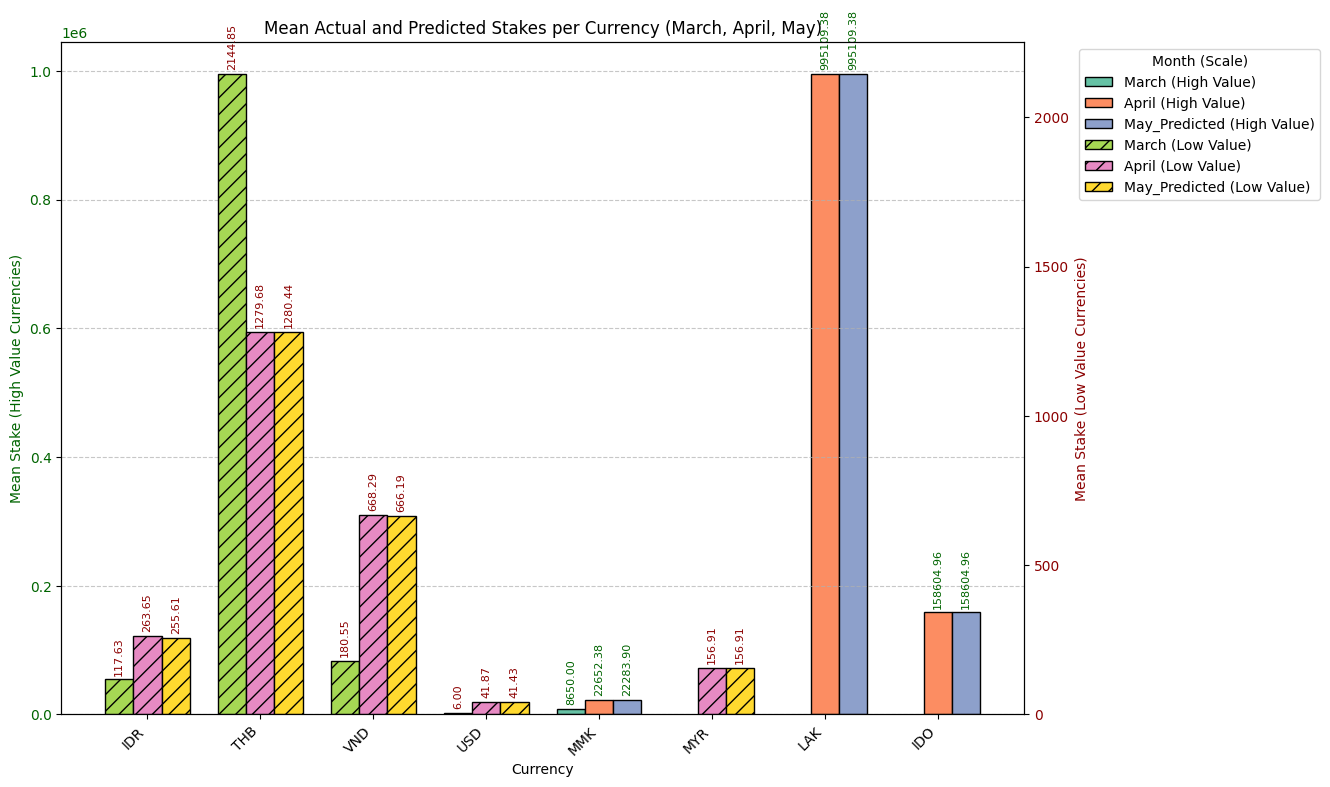

In [4]:
import matplotlib.pyplot as plt
import numpy as np # Import numpy for isnan check

# Define high and low value currencies based on observation of the summary_df
high_value_currencies = ['IDO', 'LAK', 'MMK']
low_value_currencies = ['IDR', 'THB', 'VND', 'USD', 'MYR']

# Filter the monthly_mean_stakes_df for each group
df_high = monthly_mean_stakes_df[monthly_mean_stakes_df['Currency'].isin(high_value_currencies)].copy()
df_low = monthly_mean_stakes_df[monthly_mean_stakes_df['Currency'].isin(low_value_currencies)].copy()

# Ensure all currencies are represented on the x-axis in a consistent order
all_currencies_ordered = monthly_mean_stakes_df['Currency'].unique()
currency_x_positions = {currency: i for i, currency in enumerate(all_currencies_ordered)}

fig, ax1 = plt.subplots(figsize=(15, 8))

# Define colors for months for primary and secondary axes
month_colors_primary = {
    'March': '#66c2a5',
    'April': '#fc8d62',
    'May_Predicted': '#8da0cb'
}
month_colors_secondary = {
    'March': '#a6d854',
    'April': '#e78ac3',
    'May_Predicted': '#ffd92f'
}

bar_width = 0.25 # Width of individual bars
offsets = [-bar_width, 0, bar_width] # Offsets for March, April, May_Predicted bars

# --- Plot high value currencies on ax1 (Primary Y-axis) ---
containers1 = []
for i, month in enumerate(['March', 'April', 'May_Predicted']):
    subset = df_high[df_high['Month'] == month]
    # Calculate x-coordinates based on overall currency order and bar offsets
    x_coords = [currency_x_positions[cur] + offsets[i] for cur in subset['Currency']]
    if not subset.empty:
        # Plot bars for high value currencies on ax1
        c = ax1.bar(x_coords, subset['Mean_Stake'], width=bar_width,
                    label=f'{month} (High Value)', color=month_colors_primary[month], edgecolor='black')
        containers1.append(c)

ax1.set_ylabel('Mean Stake (High Value Currencies)', color='darkgreen')
ax1.tick_params(axis='y', labelcolor='darkgreen')
ax1.set_xlabel('Currency')
ax1.set_title('Mean Actual and Predicted Stakes per Currency (March, April, May)')
ax1.set_xticks(list(currency_x_positions.values())) # Set all currency labels on x-axis
ax1.set_xticklabels(all_currencies_ordered, rotation=45, ha='right')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# --- Create a second y-axis (ax2) ---
ax2 = ax1.twinx()

# --- Plot low value currencies on ax2 (Secondary Y-axis) ---
containers2 = []
for i, month in enumerate(['March', 'April', 'May_Predicted']):
    subset = df_low[df_low['Month'] == month]
    # Calculate x-coordinates based on overall currency order and bar offsets
    x_coords = [currency_x_positions[cur] + offsets[i] for cur in subset['Currency']]
    if not subset.empty:
        # Plot bars for low value currencies on ax2 with a hatch for distinction
        c = ax2.bar(x_coords, subset['Mean_Stake'], width=bar_width,
                    label=f'{month} (Low Value)', color=month_colors_secondary[month], edgecolor='black', hatch='//')
        containers2.append(c)

ax2.set_ylabel('Mean Stake (Low Value Currencies)', color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')

# Add value labels for both axes using bar_label
for c in containers1:
    ax1.bar_label(c, fmt='%.2f', label_type='edge', fontsize=8, rotation=90, padding=3, color='darkgreen')

for c in containers2:
    ax2.bar_label(c, fmt='%.2f', label_type='edge', fontsize=8, rotation=90, padding=3, color='darkred')

# Combine legends from both axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# Place the combined legend outside the plot area
ax2.legend(handles1 + handles2, labels1 + labels2, loc='upper left', bbox_to_anchor=(1.05, 1), title='Month (Scale)')

plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to make space for the legend
plt.show()
